In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import requests
from datetime import datetime, timedelta
from pathlib import Path
import yaml
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

FONT_PATH = 'SimHei' 
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

### **1.1 Data Preperation**

In [2]:
CONFIG_PATH = Path("../data_preparation/data_apiKey/config.yaml")

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)
API_KEY = config["keys"]["fmp_api_key"]

etf_tickers = [
    # --- 权益类 ---
    'SPY',  # S&P 500
    'QQQ',  # Nasdaq 100
    'VTI',  # Total Stock Market
    'IWM',  # Russell 2000 (小盘股)
    'EFA',  # Developed Markets (非美发达市场)
    'VIG',  # Dividend Appreciation (股息成长)
    
    # --- 债券类 ---
    'AGG',  # Total Bond Market
    'IEF',  # 7-10 Year Treasury (中债)
    'HYG',  # High Yield Bond (高收益债)
    'MAIN',
    'KMLM',
    'DBMF',
    
    # --- 商品类 ---
    'GLD',  # Gold
    'DBC',  # Commodity Index
    'SLV',  # Silver

    'ALLW',
    'AOA'
]

# etf_tickers = ['TYH26']

current_date = datetime.now()

def fetch_history_stable(symbol, start_date, end_date, api_key):
    url = (
        "https://financialmodelingprep.com/stable/historical-price-eod/full"
        f"?symbol={symbol}"

        f"&apikey={api_key}"
    )
    
    for _ in range(3):
        try:
            response = requests.get(url, timeout=10)
            data = response.json()
            if isinstance(data, list) and len(data) > 0:
                df = pd.DataFrame(data)
                if "date" in df.columns and "close" in df.columns:
                    df["date"] = pd.to_datetime(df["date"])
                    df = df[["date", "close"]]
                    df.rename(columns={"close": symbol}, inplace=True)
                    df.sort_values("date", inplace=True)
                    return df
        except Exception:
            pass
    
    return pd.DataFrame()

dfs = []
for ticker in etf_tickers:
    print(f"Downloading: {ticker} ...")
    df_temp = fetch_history_stable(
        ticker,
        current_date - pd.tseries.offsets.BDay(252 * 14),
        current_date,
        API_KEY
    )
    if not df_temp.empty:
        df_temp.set_index("date", inplace=True)
        dfs.append(df_temp)

if dfs:
    final_df = pd.concat(dfs, axis=1, join="outer")
    final_df.sort_index(inplace=True)
    final_df.reset_index(inplace=True)
    final_df.rename(columns={"index": "date"}, inplace=True)
    final_df.set_index("date", inplace=True)
    # final_df.sort_index(ascending=False, inplace=True)
else:
    final_df = pd.DataFrame()

df_source = final_df.copy()
df_source

Downloading: SPY ...
Downloading: QQQ ...
Downloading: VTI ...
Downloading: IWM ...
Downloading: EFA ...
Downloading: VIG ...
Downloading: AGG ...
Downloading: IEF ...
Downloading: HYG ...
Downloading: MAIN ...
Downloading: KMLM ...
Downloading: DBMF ...
Downloading: GLD ...
Downloading: DBC ...
Downloading: SLV ...
Downloading: ALLW ...
Downloading: AOA ...


,SPY,QQQ,VTI,IWM,EFA,VIG,AGG,IEF,HYG,MAIN,KMLM,DBMF,GLD,DBC,SLV,ALLW,AOA
date,,,,,,,,,,,,,,,,,
2021-03-09,387.17,311.77,202.87,223.34,75.37,142.16,114.26,114.51,86.11,37.10,27.87,27.20,160.84,17.13,24.05,NaN,66.00
2021-03-10,389.58,310.88,204.32,227.22,75.69,143.37,114.45,114.75,86.38,37.59,27.90,27.29,161.66,17.24,24.32,NaN,66.27
2021-03-11,393.53,318.04,206.99,232.22,76.09,143.90,114.44,114.71,86.70,37.81,28.18,27.75,161.52,17.50,24.25,NaN,66.91
2021-03-12,394.06,315.46,207.40,233.59,76.28,144.65,113.79,113.88,86.46,38.39,28.41,27.89,161.49,17.42,24.03,NaN,66.86
2021-03-15,396.41,318.83,208.85,234.42,76.34,145.48,113.91,114.02,86.47,39.34,28.35,27.83,162.20,17.36,24.33,NaN,67.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,686.38,608.09,339.12,263.81,103.30,227.15,100.68,97.12,80.28,57.62,27.25,31.29,490.00,25.81,81.57,29.98,92.85
2026-03-03,680.33,601.58,335.73,259.24,100.09,225.18,100.57,97.01,80.12,57.20,27.03,30.32,468.14,25.91,74.68,29.55,91.31
2026-03-04,685.13,610.75,338.19,261.76,101.38,225.52,100.53,96.81,80.40,58.89,27.36,30.61,471.80,26.14,75.34,29.61,92.00


### **1.2 Assets Trend and Correlation Analysis**

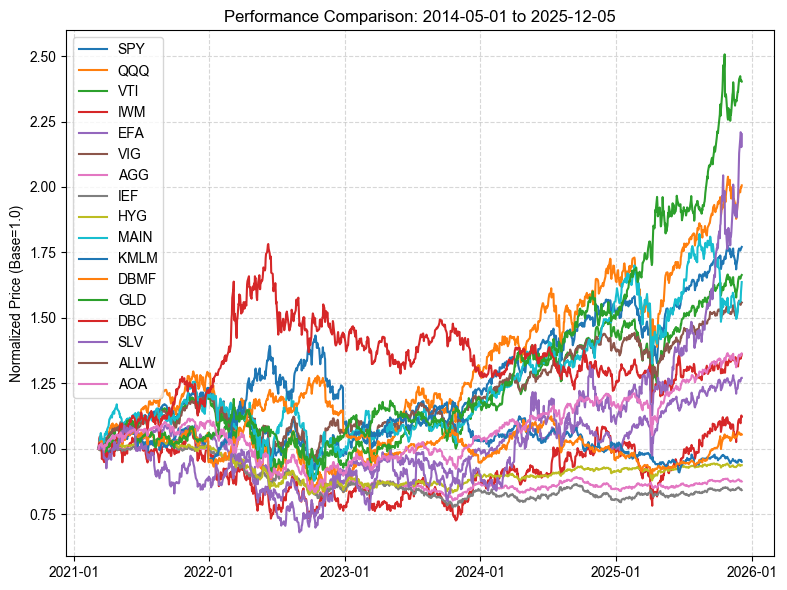

In [3]:
def plot_asset_performance(columns, start_date, end_date, df=df_source):
    data = df.loc[start_date:end_date, columns].ffill()
    if data.empty:
        print("No data available for the given date range and columns.")
        return
    normalized_data = data / data.iloc[0]
    fig, ax1 = plt.subplots(figsize=(8, 6))
    if len(columns) > 1:
        for col in columns:
            ax1.plot(normalized_data.index, normalized_data[col], label=col)
        
        ax1.set_ylabel('Normalized Price (Base=1.0)')
        ax1.set_title(f'Performance Comparison: {start_date} to {end_date}')
        ax1.legend(loc='upper left')

    elif len(columns) == 1:
        col = columns[0]
        prices = normalized_data[col]
        
        # left axis：price 
        ax1.plot(prices.index, prices, color='#1f77b4', label='Price Trend')
        ax1.set_ylabel('Normalized Price', color='#1f77b4')
        ax1.tick_params(axis='y', labelcolor='#1f77b4')
        
        # right aixs：drawdown
        running_max = prices.cummax()
        drawdown = -(running_max - prices)
        ax2 = ax1.twinx()
        ax2.bar(drawdown.index, drawdown, color='gray', alpha=0.3, width=1.0, label='Max Drawdown')
        ax2.set_ylabel('Drawdown', color='gray')
        ax2.tick_params(axis='y', labelcolor='gray')
        
        lines, labels = ax1.get_legend_handles_labels()
        bars, bar_labels = ax2.get_legend_handles_labels()
        ax1.legend(lines + bars, labels + bar_labels, loc='upper left')
        ax1.set_title(f'{col} Performance & Drawdown: {start_date} to {end_date}')

    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tight_layout()
    plt.show()

# ['SPY', 'QQQ', 'VTI', 'IWM', 'EFA', 'VIG']
# ['AGG', 'TLT', 'IEF', 'LQD', 'HYG']
# ['GLD', 'DBC', 'SLV', 'GDX', 'XLE']
plot_asset_performance(etf_tickers, '2014-05-01', '2025-12-05')

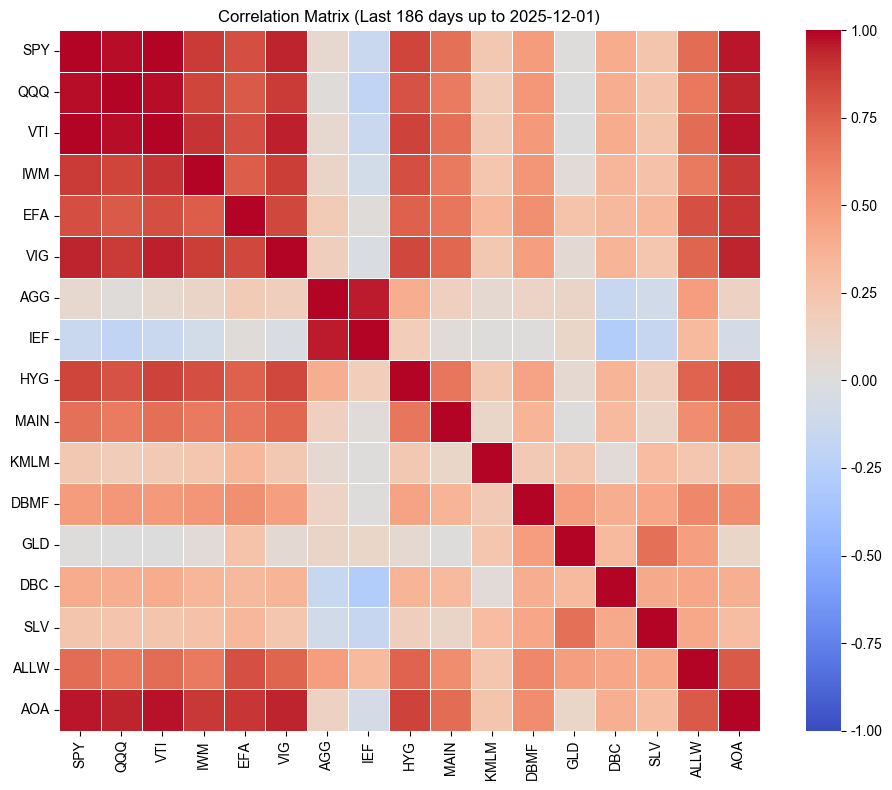

,SPY,QQQ,VTI,IWM,EFA,VIG,AGG,IEF,HYG,MAIN,KMLM,DBMF,GLD,DBC,SLV,ALLW,AOA
SPY,0.000180,2.073907e-04,0.000178,0.000183,1.234223e-04,0.000134,2.992742e-06,-6.667322e-06,0.000045,0.000147,1.559504e-05,4.103955e-05,1.577067e-06,0.000055,0.000062,0.000075,0.000120
QQQ,0.000207,2.497649e-04,0.000206,0.000207,1.373601e-04,0.000148,9.107488e-07,-1.087024e-05,0.000050,0.000161,1.580387e-05,5.024006e-05,2.114953e-07,0.000063,0.000076,0.000083,0.000138
VTI,0.000178,2.057826e-04,0.000178,0.000186,1.229449e-04,0.000134,2.991288e-06,-6.597673e-06,0.000045,0.000148,1.522355e-05,4.166755e-05,1.304310e-06,0.000054,0.000063,0.000075,0.000119
IWM,0.000183,2.065016e-04,0.000186,0.000240,1.324617e-04,0.000143,5.166914e-06,-4.765380e-06,0.000050,0.000159,1.959856e-05,5.024913e-05,6.899490e-06,0.000055,0.000078,0.000080,0.000127
EFA,0.000123,1.373601e-04,0.000123,0.000132,1.267741e-04,0.000100,6.657293e-06,8.761093e-07,0.000033,0.000119,2.024421e-05,3.900711e-05,3.913009e-05,0.000037,0.000073,0.000073,0.000093
VIG,0.000134,1.475007e-04,0.000134,0.000143,1.003284e-04,0.000112,5.266684e-06,-1.204245e-06,0.000035,0.000123,1.272886e-05,3.153983e-05,7.869356e-06,0.000038,0.000048,0.000062,0.000092
AGG,0.000003,9.107488e-07,0.000003,0.000005,6.657293e-06,0.000005,8.926815e-06,1.038557e-05,0.000005,0.000008,1.031331e-06,2.360433e-06,4.525061e-06,-0.000005,-0.000005,0.000011,0.000004
IEF,-0.000007,-1.087024e-05,-0.000007,-0.000005,8.761093e-07,-0.000001,1.038557e-05,1.321471e-05,0.000003,0.000001,2.151035e-07,2.003873e-07,5.125270e-06,-0.000010,-0.000011,0.000009,-0.000002
HYG,0.000045,5.020759e-05,0.000045,0.000050,3.309637e-05,0.000035,4.652184e-06,2.675861e-06,0.000016,0.000042,4.612966e-06,1.114609e-05,3.521922e-06,0.000014,0.000013,0.000024,0.000031
MAIN,0.000147,1.606253e-04,0.000148,0.000159,1.193901e-04,0.000123,7.769704e-06,1.423691e-06,0.000042,0.000258,8.952615e-06,3.545119e-05,3.332728e-06,0.000052,0.000036,0.000072,0.000103


In [4]:
def analyze_risk_and_correlation(columns, target_date, df=df_source, num_display=True):
    # 1. data sclicing
    subset = df.loc[:target_date, columns].tail(1000)
    
    if subset.empty:
        print("No data available for the given date and columns.")
        return None, None
    
    # 2. calculate ret1: use % returns
    returns = subset.pct_change().dropna()

    # 3. calculate covariance and correlation matrices
    cov_matrix = returns.cov()
    corr_matrix = returns.corr()

    # 4. process correlation matrix for display 
    corr_unstacked = corr_matrix.unstack()
    sorted_corr = corr_unstacked[corr_unstacked.index.get_level_values(0) < corr_unstacked.index.get_level_values(1)].sort_values(ascending=False)

    # 5. visaulization
    plt.figure(figsize=(10, 8))
    
    # mask for filtering upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=num_display, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5) # mask=mask
    
    plt.title(f'Correlation Matrix (Last {len(returns)} days up to {target_date})')
    plt.tight_layout()
    plt.show()

    return cov_matrix, sorted_corr

cols = etf_tickers

cov, corr_list = analyze_risk_and_correlation(cols, '2025-12-01', num_display = False)

# print("\n--- Top & Tail Correlations ---")
# print(corr_list.head(10), end = "\n\n")
# print(corr_list.tail(5))
# print("\n--- Covariance Matrix (Daily Returns) ---")
cov

### **1.3 All Weather Risk Budget Model**

Start backtesting: 2017-01-02 to 2025-12-01 | Optimization Mode: layer
Error: 'Date' column not found. Available columns: RangeIndex(start=0, stop=1, step=1)

========== Backtest Statistics ==========
    Year   Return Volatility Max Drawdown Sharpe Calmar
0   2021    2.27%      4.06%       -2.59%   0.07   0.88
1   2022  -11.51%     11.20%      -17.10%  -1.21  -0.67
2   2023    6.97%      7.61%       -6.49%   0.65   1.07
3   2024    7.26%      7.00%       -3.50%   0.75   2.07
4   2025   14.71%      7.01%       -6.06%   1.81   2.43
5  Total    3.09%      7.84%      -18.06%   0.14   0.17


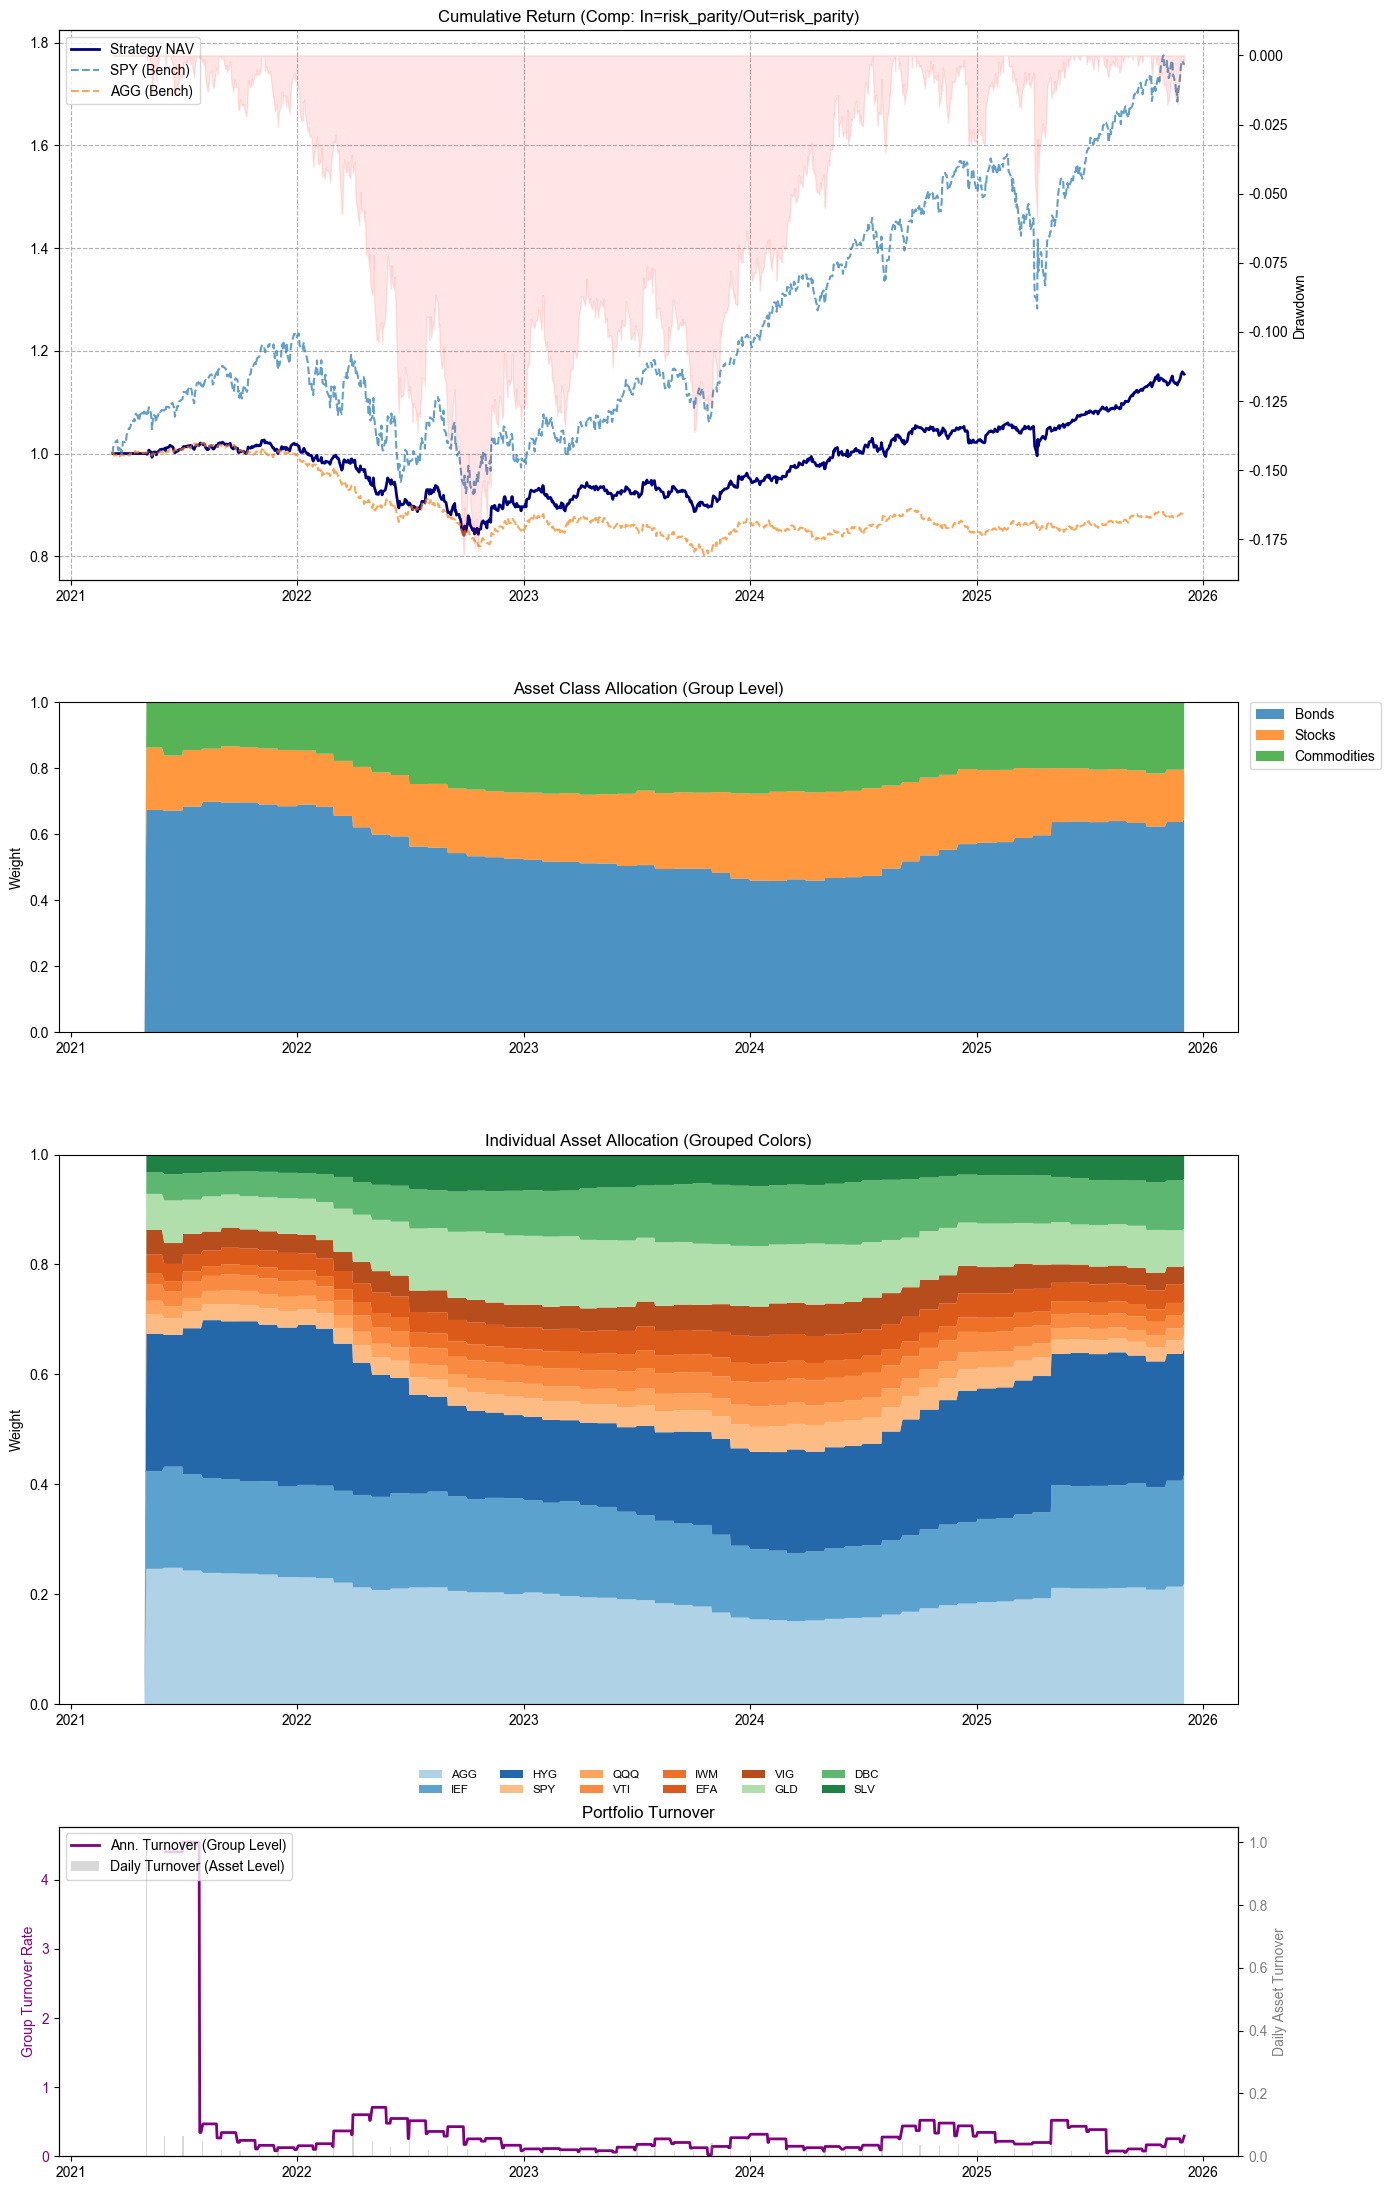

In [5]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False

def solve_risk_budget_weights(risk_budget, returns_df=None, cov_matrix=None):
    if cov_matrix is None and returns_df is None:
        raise ValueError("Must provide returns_df or cov_matrix")
    if cov_matrix is None:
        cov_matrix = returns_df.cov().values * 252
        assets = returns_df.columns
    else:
        assets = range(cov_matrix.shape[0]) if returns_df is None else returns_df.columns
    
    # cov_matrix = cov_matrix + np.eye(len(assets)) * 1e-6

    n = len(assets)
    rb = np.array(risk_budget)
    
    if len(rb) != n:
        raise ValueError(f"Risk budget length {len(rb)} does not match assets {n}")
    
    rb = np.maximum(rb, 0.0)
    if rb.sum() == 0: 
        rb = np.ones(n) / n
    else: 
        rb = rb / rb.sum()
        
    x0 = np.ones(n) / n
    
    def objective(w):
        safe_w = np.maximum(w, 1e-9) 
        port_var = np.dot(w.T, np.dot(cov_matrix, w))
        safe_rb = np.maximum(rb, 1e-9)
        log_term = np.sum(safe_rb * np.log(safe_w)) 
        return 0.5 * port_var - log_term
        
    bounds = tuple((1e-6, None) for _ in range(n))
    
    res = minimize(objective, x0, method='SLSQP', bounds=bounds, tol=1e-7, options={'maxiter': 1000, 'disp': False})
    
    if not res.success:
        print("Warning: optimization failed")
        return pd.Series(x0, index=assets)
        
    final_weights = res.x / np.sum(res.x)
    return pd.Series(final_weights, index=assets)

def optimize_portfolio_weights(returns_df, method='equal', cov_matrix=None, rf=0.02, target_value=None):
    assets = returns_df.columns
    n = len(assets)
    
    if method == 'equal': 
        return pd.Series(1.0/n, index=assets)
        
    if cov_matrix is None: 
        cov_matrix = returns_df.cov().values # * 252
        
    if method == 'risk_parity':
        target_rb = np.ones(n) / n
        return solve_risk_budget_weights(risk_budget=target_rb, cov_matrix=cov_matrix, returns_df=returns_df)
        
    if method == 'risk_budget':
        if target_value is None: 
            target_rb = np.ones(n) / n
        elif isinstance(target_value, dict):
            target_rb = [target_value.get(a, 0.0) for a in assets]
        elif isinstance(target_value, (list, np.ndarray)):
            target_rb = target_value
        else:
            target_rb = np.ones(n) / n
        return solve_risk_budget_weights(risk_budget=target_rb, cov_matrix=cov_matrix, returns_df=returns_df)

    mu = returns_df.mean().values * 252
    sigma_matrix = cov_matrix
    x0 = np.ones(n) / n
    bounds = tuple((0.0, 1.0) for _ in range(n))
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
    
    def port_vol(w): return np.sqrt(np.dot(w.T, np.dot(sigma_matrix, w)))
    def port_ret(w): return np.dot(w.T, mu)
    
    if method == 'mvt_mvp':
        res = minimize(lambda w: np.dot(w.T, np.dot(sigma_matrix, w)), x0, method='SLSQP', bounds=bounds, constraints=constraints)
    elif method == 'mvt_cml':
        def neg_sharpe(w): return - (np.dot(w.T, mu) - rf) / np.sqrt(np.dot(w.T, np.dot(sigma_matrix, w)))
        res = minimize(neg_sharpe, x0, method='SLSQP', bounds=bounds, constraints=constraints)
    elif method == 'mvt_ret':
        t_ret = target_value if target_value is not None else np.mean(mu)
        cons = constraints + [{'type': 'eq', 'fun': lambda w: port_ret(w) - t_ret}]
        res = minimize(lambda w: np.dot(w.T, np.dot(sigma_matrix, w)), x0, method='SLSQP', bounds=bounds, constraints=cons)
    elif method == 'mvt_vol':
        t_vol = target_value if target_value is not None else 0.10 
        cons = constraints + [{'type': 'ineq', 'fun': lambda w: t_vol - port_vol(w)}]
        res = minimize(lambda w: -port_ret(w), x0, method='SLSQP', bounds=bounds, constraints=cons)
    else:
        return pd.Series(1.0/n, index=assets)
        
    if not res.success: return pd.Series(1.0/n, index=assets)
    return pd.Series(res.x, index=assets)

def calculate_custom_inner_risk_budget(sub_ret, package_micro = False, macro_state = None):
    g_assets = sub_ret.columns
    n = len(g_assets)
    
    if len(sub_ret) < 20:
        return np.ones(n) / n
        
    window_sharpe = 120
    safe_window_sharpe = min(len(sub_ret), window_sharpe)
    mean_ret = sub_ret.tail(abs(safe_window_sharpe)).mean()
    std_ret = sub_ret.tail(safe_window_sharpe).std()
    feat_sharpe = mean_ret / (std_ret + 1e-9)
    
    # Kaufman Efficiency Ratio (趋势效率)
    window_ker = 60
    safe_window_ker = min(len(sub_ret), window_ker)
    subset_ker = sub_ret.tail(safe_window_ker)
    # print(subset_ker.sum())
    direction = subset_ker.sum().abs() 
    volatility_sum = subset_ker.abs().sum()
    feat_ker = direction / (volatility_sum + 1e-9)
    
    # 短期（20天）波动率的倒数
    window_vol = 20
    safe_window_vol = min(len(sub_ret), window_vol)
    current_vol = sub_ret.tail(safe_window_vol).std()
    feat_inv_vol = (current_vol + 1e-9)
    
    factors = pd.DataFrame({
        'sharpe': feat_sharpe,
        'ker': feat_ker,
        'inv_vol': feat_inv_vol
    }, index=g_assets)
    
    ranks_pos = factors.rank(axis=0, pct=True, ascending=True)
    ranks_neg = factors.rank(axis=0, pct=True, ascending=False)
    
    # final_score = (ranks_neg['sharpe'] * 0.1) + (ranks_pos['ker'] * 0.8) + (ranks_pos['inv_vol'] * 0.1)
    final_score = (ranks_pos['sharpe'] * 0.2) + (ranks_pos['ker'] * 0.5) + (ranks_neg['inv_vol'] * 0.3)
    # final_score = (ranks_neg['sharpe'] * 0) + (ranks_neg['ker'] * 0) + (ranks_neg['inv_vol'] * 1)
    
    target_rb = final_score / final_score.sum()
    
    if target_rb.isnull().any():
        return np.ones(n) / n
        
    if package_micro and macro_state is not None:
        assets_china_stock = ['000905.SH', '000300.SH', 'NDX.GI', 'N225.GI', '中证2000','HSTECH.HI'] 
        assets_global_stock = [ 'NDX.GI', 'N225.GI', '中证2000','HSTECH.HI'] 
        asset_gold = ['AU.SHF']
        
        if 'growth' in macro_state:
            has_stock_assets = any(x in g_assets for x in assets_china_stock + assets_global_stock)
            if has_stock_assets:
                if macro_state['growth'] > 0:
                    valid_tokens = assets_china_stock
                else:
                    valid_tokens = assets_global_stock
                
                for asset in g_assets:
                    is_stock_category = (asset in assets_china_stock) or (asset in assets_global_stock)
                    if is_stock_category and (asset not in valid_tokens):
                        target_rb[asset] = 0.0
                
                if target_rb.sum() > 0:
                    target_rb = target_rb / target_rb.sum()

        # 2.2 汇率逻辑 (Currency) -> 调整商品/黄金权重
        # 假设: 汇率上行(macro_state['currency'] > 0) = 贬值 = 利好黄金
        if 'currency' in macro_state and macro_state['currency'] > 0:
            gold_targets = [g for g in asset_gold if g in g_assets]
            
            if gold_targets:
                gold_col = gold_targets[0] 
                target_weight_gold = 0.5
                current_others_sum = target_rb.drop(gold_col).sum()
                if current_others_sum > 0:
                    # 压缩其他资产权重
                    scale_factor = (1 - target_weight_gold) / current_others_sum
                    target_rb = target_rb * scale_factor
                    target_rb[gold_col] = target_weight_gold # 覆盖黄金权重
                else:
                    target_rb[:] = 0.0
                    target_rb[gold_col] = 1.0
                    
    if target_rb.sum() == 0:
         return np.ones(n) / n
         
    return target_rb / target_rb.sum()

def calculate_60_day_return(macro_df, col_name, current_date, lag_days=60):
    date_indices = macro_df.index.get_loc(current_date) - np.array([lag_days * i for i in range(1, 6)])
    date_indices = date_indices[date_indices >= 0]
    
    returns = []
    for i in date_indices:
        current_value = macro_df.iloc[i][col_name]
        past_value = macro_df.iloc[i - lag_days][col_name] if i - lag_days >= 0 else current_value
        return_pct = (current_value - past_value) / past_value
        returns.append(return_pct)
    
    return np.mean([abs(x) for x in returns]) if returns else 0.0

def calculate_dynamic_macro_weights(current_date, macro_df, returns, score_way='ranking', weather_parity=False):
    col_gdp = "中国:GDP:不变价:同比"
    col_cpi = "中国:CPI:同比"
    col_rate = "中国:逆回购利率:7天"
    col_exchange = "中间价:美元兑人民币"  # 注：数值上升代表人民币贬值
    col_pmi = "中国:制造业PMI"

    # 输出顺序定义: [Stocks, Bonds, Commodities]
    trend_state = {'growth': 0, 'inflation': 0, 'rates': 0, 'currency': 0}
    
    final_weights = np.array([0.33, 0.33, 0.34])  # Default initialization

    if score_way == 'ranking':
        lag_days = 60
        sensitivity = 2
        
        if current_date not in macro_df.index:
            current_idx = macro_df.index.searchsorted(current_date)
            if current_idx >= len(macro_df): current_idx = len(macro_df) - 1
            current_date_lookup = macro_df.index[current_idx]
        else:
            current_date_lookup = current_date
            
        prev_date_target = current_date_lookup - pd.Timedelta(days=lag_days)
        prev_idx = macro_df.index.searchsorted(prev_date_target)
        if prev_idx >= len(macro_df): prev_idx = len(macro_df) - 1
        prev_date_lookup = macro_df.index[prev_idx]
        
        try:
            curr_vals = macro_df.loc[current_date_lookup]
            prev_vals = macro_df.loc[prev_date_lookup]
        except KeyError:
            return np.array([0.33, 0.33, 0.34]) 

        delta_gdp = (curr_vals[col_gdp] - prev_vals[col_gdp])
        delta_cpi = (curr_vals[col_cpi] - prev_vals[col_cpi]) 
        delta_rate = (curr_vals[col_rate] - prev_vals[col_rate]) 
        delta_pmi = (curr_vals[col_pmi] - prev_vals[col_pmi]) 
        delta_exchange = (curr_vals[col_exchange] - prev_vals[col_exchange]) / abs(prev_vals[col_exchange] + 1e-9)
        # print(delta_gdp, delta_cpi, delta_rate, delta_pmi, delta_exchange)

        trend_state['growth'] = 1 if (delta_gdp) > 0 else -1
        trend_state['inflation'] = 1 if delta_cpi > 0 else -1
        trend_state['rates'] = 1 if delta_rate > 0 else -1
        trend_state['currency'] = 1 if delta_exchange > 0 else -1

        # 向量维度: [Stocks, Bonds, Commodities]
        vec_growth = np.array([1.0, -1.0, 0.8])    
        vec_inflation = np.array([-0.5, -1.0, 1.0]) 
        vec_rates = np.array([-0.5, -1.5, -0])
        vec_currency = np.array([-0.2, -0.2, 0.8])

        raw_scores = (
            delta_gdp * vec_growth * 0.6 + 
            delta_pmi * vec_growth * 0.4 + 
            delta_cpi * vec_inflation + 
            delta_rate * vec_rates + 
            delta_exchange * vec_currency
        )
        
        exp_scores = np.exp(raw_scores * sensitivity)
        final_weights = exp_scores / np.sum(exp_scores)
        final_weights = np.maximum(final_weights, 0.05)
        final_weights = final_weights / np.sum(final_weights)

        
    elif score_way == 'percentile':
        # --- 分支 2: 分位数计算 (Percentile) ---
        lag_days = 60
        sensitivity = 2
        
        if current_date not in macro_df.index:
            current_idx = macro_df.index.searchsorted(current_date)
            if current_idx >= len(macro_df): current_idx = len(macro_df) - 1
            current_date_lookup = macro_df.index[current_idx]
        else:
            current_date_lookup = current_date
            
        prev_date_target = current_date_lookup - pd.Timedelta(days=lag_days)
        prev_idx = macro_df.index.searchsorted(prev_date_target)
        if prev_idx >= len(macro_df): prev_idx = len(macro_df) - 1
        prev_date_lookup = current_date_lookup - pd.Timedelta(days=lag_days)
        
        try:
            curr_vals = macro_df.loc[current_date_lookup]
        except KeyError:
            return np.array([0.33, 0.33, 0.34]), trend_state

        # Calculate the z-scores based on percentiles
        delta_gdp = (curr_vals[col_gdp] - macro_df[col_gdp].mean()) / macro_df[col_gdp].std()
        delta_cpi = (curr_vals[col_cpi] - macro_df[col_cpi].mean()) / macro_df[col_cpi].std()
        delta_rate = (curr_vals[col_rate] - macro_df[col_rate].mean()) / macro_df[col_rate].std()
        delta_pmi = (curr_vals[col_pmi] - macro_df[col_pmi].mean()) / macro_df[col_pmi].std()
        delta_exchange = (curr_vals[col_exchange] - macro_df[col_exchange].mean()) / macro_df[col_exchange].std()

        trend_state['growth'] = 1 if (delta_gdp + delta_pmi) > 0 else -1
        trend_state['inflation'] = 1 if delta_cpi > 0 else -1
        trend_state['rates'] = 1 if delta_rate > 0 else -1
        trend_state['currency'] = 1 if delta_exchange > 0 else -1

        # 向量维度: [Stocks, Bonds, Commodities]
        vec_growth = np.array([1.0, -1.0, 0.8]) 
        vec_inflation = np.array([-0.5, -1.0, 1.0])
        vec_rates = np.array([-0.5, -1.5, -0.2])
        vec_currency = np.array([-0.2, -0.2, 0.8])

        raw_scores = (
            delta_gdp * vec_growth * 0.6 + 
            delta_pmi * vec_growth * 0.4 + 
            delta_cpi * vec_inflation + 
            delta_rate * vec_rates + 
            delta_exchange * vec_currency
        )

        exp_scores = np.exp(raw_scores * sensitivity)
        final_weights = exp_scores / np.sum(exp_scores)
        final_weights = np.maximum(final_weights, 0.05)
        final_weights = final_weights / np.sum(final_weights)

    if True:
        t_g = trend_state['growth']
        t_i = trend_state['inflation']
        t_r = trend_state['rates']
        t_c = trend_state['currency']
        # print(t_g, t_i, t_r, t_c)
        
        # 调整量 (Stocks, Bonds, Commodities)
        adj_vector = np.array([0.0, 0.0, 0.0])
        
        # if t_g > 0 and t_i > 0:
        #     adj_vector += np.array([-0.05, -0.15, 0.20])
        # if t_g > 0 and t_i <= 0:
        #     # [复苏 Recovery]: 经济热，通胀低 -> 股票为王
        #     adj_vector += np.array([0.2, -0.05, -0.10])
        # if t_g <= 0 and t_i > 0:
        #     # [滞胀 Stagflation]: 经济差，通胀起 -> 商品(避险/抗通胀)，股债双杀
        #     adj_vector += np.array([-0.10, -0.10, 0.20])
        if t_g <= 0 and t_i <= 0:
            # [衰退 Recession]: 经济差，通胀低 -> 债券为主
            adj_vector += np.array([-0.10, 0.20, -0.10])
            
        if t_r > 0 and t_c > 0:
            adj_vector += np.array([0.05, 0.05, 0.0])
        elif t_c <= 0:
            adj_vector += np.array([0.0, 0.0, -0.7])
            
        final_weights = final_weights + adj_vector
        final_weights = np.maximum(final_weights, 0.05) # 保持最低5%仓位
        final_weights = final_weights / np.sum(final_weights)
        
    if weather_parity:
        # Calculate and print the volatility for each major asset class
        # Assuming asset_groups contain the correct asset class categories for [Bonds, Stocks, Commodities]

        # Extract the data for each asset class
        bonds_returns = returns[bonds_lst].mean(axis=1)
        stocks_returns = returns[stocks_lst].mean(axis=1)
        comm_returns = returns[comm_lst].mean(axis=1)

        # Calculate the volatility (standard deviation of returns)
        # bonds_vol = bonds_returns.std() * np.sqrt(252)  # Annualized volatility
        # stocks_vol = stocks_returns.std() * np.sqrt(252)
        # comm_vol = comm_returns.std() * np.sqrt(252)
        # print(f"Volatility of Bonds: {bonds_vol:.2%}")
        # print(f"Volatility of Stocks: {stocks_vol:.2%}")
        # print(f"Volatility of Commodities: {comm_vol:.2%}")

        # Set initial risk budget for each class as 1/3
        risk_budget = np.array([0.9, 0.05, 0.05])

        # Adjust final weights with the calculated volatilities if needed
        final_weights = risk_budget + \
            delta_gdp * np.array([0.05, -0.05, 0.04]) * 0.6 + \
            delta_cpi * np.array([-0.025, -0.05, 0.05]) + \
            delta_pmi * np.array([0.05, -0.05, 0.04]) * 0.4 + \
            delta_rate * np.array([-0.025, -0.725, -0.01]) + \
            delta_exchange * np.array([-0.2, -0.2, 0.8]) / 7
        
        final_weights = np.maximum(final_weights, 0.01)
        final_weights = final_weights / np.sum(final_weights)

    # print(final_weights)
    return final_weights, trend_state

def apply_correlation_filter(current_assets, full_returns, current_date, threshold=1.0):
    if threshold >= 1.0 or threshold <= 0:
        return current_assets
    
    subset = full_returns.loc[:current_date, current_assets].tail(240)
    if len(subset) < 30:
        return current_assets
        
    corr_matrix = subset.corr()
    assets_to_drop = set()
    
    cols = corr_matrix.columns
    violations = []
    
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            asset_a = cols[i]
            asset_b = cols[j]
            corr_val = corr_matrix.iloc[i, j]
            if corr_val > threshold:
                violations.append((asset_a, asset_b, corr_val))
    
    violations.sort(key=lambda x: x[2], reverse=True)
    
    for asset_a, asset_b, corr_val in violations:
        if asset_a in assets_to_drop or asset_b in assets_to_drop:
            continue
            
        print(f"Warning: Correlation Alert ({corr_val:.4f}) between {asset_a} and {asset_b} on {current_date.date()}")
        
        remaining_pool = [c for c in cols if c not in [asset_a, asset_b] and c not in assets_to_drop]
        
        if not remaining_pool:
            assets_to_drop.add(asset_a)
            print(f"  -> Dropping {asset_a} (No other assets to compare)")
            continue

        max_corr_a = corr_matrix.loc[asset_a, remaining_pool].max()
        max_corr_b = corr_matrix.loc[asset_b, remaining_pool].max()
        
        if np.isnan(max_corr_a): max_corr_a = -1
        if np.isnan(max_corr_b): max_corr_b = -1
        
        if max_corr_a > max_corr_b:
            assets_to_drop.add(asset_a)
            print(f"  -> Dropping {asset_a} (Max Other Corr: {max_corr_a:.2f} > {max_corr_b:.2f})")
        else:
            assets_to_drop.add(asset_b)
            print(f"  -> Dropping {asset_b} (Max Other Corr: {max_corr_b:.2f} >= {max_corr_a:.2f})")
            
    filtered_assets = [c for c in current_assets if c not in assets_to_drop]
    return filtered_assets

def plot_rolling_distribution(nav_series, look_forward=250, start_offset=250, end_offset=250):
    max_start_idx = len(nav_series) - look_forward
    if max_start_idx <= start_offset:
        print("Not enough history.")
        return

    paths = []
    final_returns = []
    
    sample_indices = range(start_offset, max_start_idx, 5) 
    
    for t in sample_indices:
        segment = nav_series.iloc[t : t + look_forward].values
        normalized_path = segment / segment[0]
        paths.append(normalized_path)
        final_returns.append(normalized_path[-1])

    if not paths: return
    win_rate = sum(1 for ret in final_returns if ret > 1.0) / len(final_returns)
    paths_array = np.array(paths)
    
    plt.figure(figsize=(12, 6))
    plt.plot(paths_array.T, color='gray', alpha=0.05)
    mean_path = np.mean(paths_array, axis=0)
    plt.plot(mean_path, color='navy', linewidth=3, label='Average Path')
    median_path = np.median(paths_array, axis=0)
    plt.plot(median_path, color='orange', linewidth=2, linestyle='--', label='Median Path')

    plt.title(f'Historical Rolling {look_forward}-Day Performance')
    plt.xlabel('Days After Entry')
    plt.ylabel('Normalized NAV (Start=1.0)')
    plt.text(0.05, 0.90, f"Positive Outcome Rate: {win_rate:.2%}", transform=plt.gca().transAxes, fontsize=14, bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
    plt.axhline(1.0, color='black', linestyle=':', linewidth=1)
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    plt.show()

def backtest_risk_parity(start_date, end_date, asset_groups, freq='ME', tv_delay=0, lookback_window=252, 
                         benchmark_assets=None, df=None, 
                         global_weight='composite', # 'composite' implies we look at optimization param
                         target_return=0.10, 
                         target_vol=0.10,
                         inner_weight='risk_parity', 
                         outer_weight='risk_parity',
                         inner_target_ret=0.10, 
                         inner_target_vol=0.10,
                         outer_target_ret=0.08, 
                         outer_target_vol=0.05,
                         macro_view={'growth': 'up', 'inflation': 'up', 'rates': 'down', 'currency': 'up'},
                         customize_naive=None,
                         macro_df=None,
                         rf=0.02,
                         corr_filter=0.9,
                         score_way='ranking',
                         package_macro=False,
                         package_micro=False,
                         global_vol = None,
                         weather_parity = False,
                         optimization = "layer",
                         limit_1 = False): # New default parameter
    
    if df is None: return None, None, None, None, None
    
    all_assets = [item for sublist in asset_groups for item in sublist]
    valid_assets = [c for c in all_assets if c in df.columns]
    
    data_start_idx = pd.Timestamp(start_date) - pd.tseries.offsets.BusinessDay(lookback_window + 50)
    prices = df.loc[data_start_idx:end_date, valid_assets].ffill()
    returns = prices.pct_change().dropna()
    
    rebalance_dates = pd.date_range(start=start_date, end=end_date, freq=freq)
    if tv_delay > 0:
        rebalance_dates = [d + pd.tseries.offsets.BusinessDay(tv_delay) for d in rebalance_dates]
    rebalance_dates = [d for d in rebalance_dates if d <= pd.Timestamp(end_date)]
    if not rebalance_dates or rebalance_dates[0] > pd.Timestamp(start_date):
        rebalance_dates = [pd.Timestamp(start_date)] + list(rebalance_dates)

    weights_df = pd.DataFrame(index=returns.index, columns=valid_assets).fillna(0.0)
    
    group_names = ['Bonds', 'Stocks', 'Commodities']
    
    volatility_records = []
    rb_records = []
    
    valid_rebalance_dates = sorted(list(set([d for d in rebalance_dates if d >= returns.index[0] and d <= returns.index[-1]])))
    if pd.Timestamp(start_date) not in valid_rebalance_dates:
        start_idx = returns.index.searchsorted(pd.Timestamp(start_date))
        if start_idx < len(returns):
            valid_rebalance_dates.insert(0, returns.index[start_idx])
            valid_rebalance_dates = sorted(list(set(valid_rebalance_dates)))

    print(f"Start backtesting: {start_date} to {end_date} | Optimization Mode: {optimization}")
    
    # Check if we are using a standard global optimization (like Mean-Variance) that ignores the custom logic
    is_standard_global_opt = global_weight in ['mvt_mvp', 'mvt_ret', 'mvt_vol', 'mvt_cml', 'equal', 'risk_budget'] and optimization != 'global'
    
    # Static Rules for Macro
    macro_static_rules = {
        'growth': {'up': {'Stocks': 7.5, 'Commodities': 7.5}, 'down': {'Bonds': 7.5, 'Commodities': 7.5}},
        'inflation': {'up': {'Commodities': 10.0}, 'down': {'Bonds': 10.0}},
        'rates': {'up': {'Stocks': 12.5}, 'down': {'Bonds': 12.5}},
        'currency': {'up': {'Stocks': 12.5}, 'down': {'Commodities': 12.5}}
    }

    for i, reb_date in enumerate(valid_rebalance_dates):
        window_data = returns.loc[:reb_date].tail(lookback_window)
        if len(window_data) < 20: continue

        current_period_universe = [c for c in valid_assets if c in window_data.columns]
        try:
            filtered_universe = apply_correlation_filter(current_period_universe, returns, reb_date, threshold=corr_filter)
        except NameError:
            filtered_universe = current_period_universe
        
        current_vol_row = {'Date': reb_date}
        daily_target_weight = pd.Series(0.0, index=valid_assets)

        if global_vol is not None:
            # 1. Select valid assets for this window
            valid_assets_window = [a for a in filtered_universe if a in window_data.columns]
            if valid_assets_window:
                sub_ret = window_data[valid_assets_window]
                
                # 2. Calculate current annualized volatility for all assets
                asset_stds = sub_ret.std() * np.sqrt(252)
                
                # 3. Calculate Leverage Scaling Factor
                # Target: Make asset volatility equal to global_vol
                # Formula: Factor = Global_Vol / Asset_Vol
                # Avoid division by zero by replacing 0 with inf (resulting in 0 weight eventually if handled, or just filter)
                leverage_factors = global_vol / asset_stds.replace(0, np.inf)
                
                # 4. Construct "Scaled Returns" (Virtual Assets)
                # These virtual assets all have volatility approx equal to global_vol
                scaled_returns = sub_ret * leverage_factors
                # print("Date:", reb_date)
                # print(asset_stds)
                
                # 5. Perform Risk Parity (ERC) on the Scaled Universe
                # We want Equal Risk Contribution among these "Equal Volatility" instruments.
                # Note: If correlations were all zero, weights would be 1/N. 
                # With correlations, this solves for true ERC on the levered assets.
                scaled_cov = scaled_returns.cov().values * 252
                n_assets = len(valid_assets_window)
                rb_vector = np.array([1.0/n_assets] * n_assets)
                
                # weights_on_scaled sums to 1.0 (allocation within the virtual portfolio)
                weights_on_scaled = solve_risk_budget_weights(
                    risk_budget=rb_vector,
                    cov_matrix=scaled_cov,
                    returns_df=scaled_returns
                )
                
                # 6. Convert back to Actual Weights
                # Final Weight = Weight_in_Virtual_PF * Leverage_Factor
                final_weights_series = weights_on_scaled * leverage_factors.values

                if limit_1:
                    limit_factor = min(1, final_weights_series[bonds_lst].sum()) / final_weights_series[bonds_lst].sum()
                    final_weights_series[bonds_lst] = limit_factor * final_weights_series[bonds_lst]

                # print(final_weights_series[bonds_lst].sum())
                
                daily_target_weight[valid_assets_window] = final_weights_series
                
                # Record Vol stats for logging
                for asset, vol in zip(valid_assets_window, asset_stds): 
                    current_vol_row[asset] = vol

                current_rb_row = pd.DataFrame(rb_vector.reshape(1, -1), columns=all_assets, index=[reb_date]).rename_axis('Date')
                current_rb_row = {'Date': reb_date, **current_rb_row.iloc[0].to_dict()}

            # -----------------------------------------------------------
            # CASE A: Standard Global Optimization (MVT, etc.) - No Macro Logic
            # -----------------------------------------------------------
        else:
            if is_standard_global_opt:
                valid_assets_window = [a for a in filtered_universe if a in window_data.columns]
                curr_target = None
                if 'ret' in global_weight: curr_target = target_return
                elif 'vol' in global_weight: curr_target = target_vol
                
                w_global = optimize_portfolio_weights(
                    window_data[valid_assets_window], 
                    method=global_weight, 
                    rf=rf, 
                    target_value=curr_target
                )
                daily_target_weight[valid_assets_window] = w_global
                
                sub_std = window_data[valid_assets_window].std() * np.sqrt(252)
                for asset, vol in zip(valid_assets_window, sub_std): current_vol_row[asset] = vol

                rb_vector = np.array([1.0/len(valid_assets_window)] * len(valid_assets_window))
                current_rb_row = pd.DataFrame(rb_vector.reshape(1, -1), columns=all_assets, index=[reb_date]).rename_axis('Date')
                current_rb_row = {'Date': reb_date, **current_rb_row.iloc[0].to_dict()}

            # -----------------------------------------------------------
            # CASE B: Global Risk Budget Optimization (Outer RB * Inner RB -> Solve Global)
            # -----------------------------------------------------------
            elif optimization == 'global':
                # 1. Calculate Outer Risk Budget (Group Level)
                group_rb_dict = {}
                calculated_weights = np.array([0.33, 0.33, 0.33]) # Default
                
                if customize_naive is not None and macro_df is not None:
                    if outer_weight == "customize":
                        calculated_weights, trend_weight = calculate_dynamic_macro_weights(reb_date, macro_df, returns, score_way=score_way, weather_parity=weather_parity)
                        mapper = {'Stocks': calculated_weights[0], 'Bonds': calculated_weights[1], 'Commodities': calculated_weights[2]} 
                        for g in group_names:
                            group_rb_dict[g] = mapper.get(g, 0.0)
                    else:
                        print("Unsupported case!!")
                else:
                    temp_dict = {g: 0.0 for g in group_names}
                    for factor, direction in macro_view.items():
                        allocs = macro_static_rules.get(factor, {}).get(direction, {})
                        for asset_class, weight_val in allocs.items():
                            if asset_class in temp_dict:
                                temp_dict[asset_class] += weight_val
                    
                    # Normalize static weights
                    total_static = sum(temp_dict.values())
                    if total_static > 0:
                        group_rb_dict = {k: v / total_static for k, v in temp_dict.items()}
                    else:
                        group_rb_dict = {g: 1.0/len(group_names) for g in group_names}

                # print(group_rb_dict)
                
                # 2. Calculate Global Risk Budget per Asset
                global_asset_rb = pd.Series(0.0, index=filtered_universe)
                
                # Trend weight for inner calculation (if needed)
                _, trend_weight_for_inner = calculate_dynamic_macro_weights(reb_date, macro_df, returns, score_way=score_way) if macro_df is not None else (None, None)

                for g_idx, assets in enumerate(asset_groups):
                    g_name = group_names[g_idx] if g_idx < len(group_names) else f"Group_{g_idx}"
                    g_assets = [a for a in assets if a in window_data.columns and a in filtered_universe]
                    
                    if not g_assets: continue
                    
                    # Get Group Risk Budget
                    outer_rb_val = group_rb_dict.get(g_name, 0.0)
                    if outer_rb_val == 0: continue

                    # Get Inner Risk Budget (Asset|Group)
                    sub_ret = window_data[g_assets]
                    if inner_weight == 'customize':
                        inner_rb_series = calculate_custom_inner_risk_budget(sub_ret, package_micro, macro_state=trend_weight_for_inner)
                    else:
                        inner_rb_series = pd.Series(1.0/len(g_assets), index=g_assets)
                    
                    # Global RB = Group RB * Inner RB
                    # Note: inner_rb_series should sum to 1.0
                    asset_contribution = inner_rb_series * outer_rb_val ############
                    global_asset_rb[g_assets] = asset_contribution

                # 3. Solve for Weights Globally
                # We use the full covariance matrix of the valid universe
                valid_assets_window = global_asset_rb.index.tolist()
                full_cov_matrix = window_data[valid_assets_window].cov().values * 252
                
                # Solve
                final_w_series = solve_risk_budget_weights(
                    risk_budget=global_asset_rb.values, 
                    cov_matrix=full_cov_matrix, 
                    returns_df=window_data[valid_assets_window] # Pass for column names
                )
                
                daily_target_weight[valid_assets_window] = final_w_series
                
                # Record Vol stats
                sub_std = window_data[valid_assets_window].std() * np.sqrt(252)
                for asset, vol in zip(valid_assets_window, sub_std): current_vol_row[asset] = vol
                
                current_rb_row = global_asset_rb.to_dict()
                current_rb_row = {'Date': reb_date, **global_asset_rb.to_dict()}

            # -----------------------------------------------------------
            # CASE C: Layered Optimization (Inner Opt -> Synthetic -> Outer Opt)
            # -----------------------------------------------------------
            else: # optimization == 'layer'
                inner_weights = {} 
                group_synthetic_returns = pd.DataFrame(index=window_data.index)
                calculated_weights = None 

                # 1. Inner Optimization
                for g_idx, assets in enumerate(asset_groups):
                    g_name = group_names[g_idx] if g_idx < len(group_names) else f"Group_{g_idx}"
                    g_assets = [a for a in assets if a in window_data.columns and a in filtered_universe]
                    if not g_assets: continue
                    
                    if inner_weight == 'customize':
                        sub_ret = window_data[g_assets]
                        _, trend_weight = calculate_dynamic_macro_weights(reb_date, macro_df, returns, score_way=score_way, weather_parity=weather_parity)
                        target_rb_inner = calculate_custom_inner_risk_budget(sub_ret, package_micro, macro_state=trend_weight)
                        w_inner = solve_risk_budget_weights(risk_budget=target_rb_inner.values, returns_df=sub_ret)
                    else:
                        t_val_in = None
                        if 'ret' in inner_weight: t_val_in = inner_target_ret
                        if 'vol' in inner_weight: t_val_in = inner_target_vol
                        w_inner = optimize_portfolio_weights(window_data[g_assets], method=inner_weight, rf=rf, target_value=t_val_in)
                    
                    inner_weights[g_name] = w_inner
                    group_synthetic_returns[g_name] = (window_data[g_assets] * w_inner).sum(axis=1)
                    
                    sub_std = window_data[g_assets].std() * np.sqrt(252)
                    for asset, vol in zip(g_assets, sub_std): current_vol_row[asset] = vol
                
                # 2. Outer Optimization
                valid_groups = list(group_synthetic_returns.columns)
                if valid_groups:
                    t_val_out = None
                    
                    if outer_weight == 'customize':
                        rb_dict = {}
                        if customize_naive is not None and macro_df is not None:
                            calculated_weights, trend_weight = calculate_dynamic_macro_weights(reb_date, macro_df, returns, score_way=score_way, weather_parity=weather_parity)
                            mapper = {
                                'Stocks': calculated_weights[0],
                                'Bonds': calculated_weights[1],
                                'Commodities': calculated_weights[2]
                            }
                            for g in group_names:
                                rb_dict[g] = mapper.get(g, 0.0)
                        else:
                            rb_dict = {g: 0.0 for g in group_names}
                            for factor, direction in macro_view.items():
                                allocs = macro_static_rules.get(factor, {}).get(direction, {})
                                for asset_class, weight_val in allocs.items():
                                    if asset_class in rb_dict:
                                        rb_dict[asset_class] += weight_val
                        
                        target_rb_vector = [rb_dict.get(g, 0.0) for g in valid_groups]
                        sum_rb = sum(target_rb_vector)
                        if sum_rb > 0:
                            target_rb_vector = [x / sum_rb for x in target_rb_vector]
                        else:
                            target_rb_vector = [1.0/len(target_rb_vector)] * len(target_rb_vector)

                        outer_alloc = optimize_portfolio_weights(
                            group_synthetic_returns, 
                            method='risk_budget', 
                            rf=rf, 
                            target_value=target_rb_vector
                        )
                    else:
                        if 'ret' in outer_weight: t_val_out = outer_target_ret
                        if 'vol' in outer_weight: t_val_out = outer_target_vol
                        outer_alloc = optimize_portfolio_weights(group_synthetic_returns, method=outer_weight, rf=rf, target_value=t_val_out)
                    
                    # 3. Combine Weights
                    for g_name, w_out in outer_alloc.items():
                        if g_name in inner_weights:
                            w_in_series = inner_weights[g_name]
                            for asset, w_in in w_in_series.items():
                                daily_target_weight[asset] = w_out * w_in
                
                current_rb_row = None

        # -----------------------------------------------------------
        # Common End of Loop Logic
        # -----------------------------------------------------------
        volatility_records.append(current_vol_row)
        rb_records.append(current_rb_row)
        
        start_apply = reb_date
        end_apply = valid_rebalance_dates[i+1] if i < len(valid_rebalance_dates)-1 else returns.index[-1]
        period_idx = returns.loc[start_apply:end_apply].index
        for idx in period_idx: 
            weights_df.loc[idx] = daily_target_weight

    # --- Post-Processing and Plotting (Same as before) ---
    volatility_df = pd.DataFrame(volatility_records)
    if not volatility_df.empty: volatility_df.set_index('Date', inplace=True)

    rb_df = pd.DataFrame(rb_records)
    if 'Date' in rb_df.columns:
        rb_df.set_index('Date', inplace=True)
    else:
        print("Error: 'Date' column not found. Available columns:", rb_df.columns)
        
    weights_df = weights_df.loc[start_date:end_date].ffill()
    returns_backtest = returns.loc[start_date:end_date]
    weights_df = weights_df.reindex(returns_backtest.index).ffill()
    
    portfolio_ret = (weights_df.shift(1) * returns_backtest).sum(axis=1)
    portfolio_ret.iloc[0] = 0 
    nav = (1 + portfolio_ret).cumprod()
    
    group_weights_hist = pd.DataFrame(index=weights_df.index)
    for i, grp in enumerate(asset_groups):
        g_name = group_names[i] if i < len(group_names) else f"G{i}"
        valid_cols = [c for c in grp if c in weights_df.columns]
        group_weights_hist[g_name] = weights_df[valid_cols].sum(axis=1)

    daily_turnover_group = group_weights_hist.diff().abs().sum(axis=1).fillna(0.0)
    annualized_turnover_group = daily_turnover_group.rolling(60).mean() * 252
    daily_turnover_asset = weights_df.diff().abs().sum(axis=1).fillna(0.0)

    stats_list = []
    years = sorted(returns_backtest.index.year.unique())
    for year in years:
        sub_ret = portfolio_ret[portfolio_ret.index.year == year]
        if sub_ret.empty: continue
        ann_ret = (1 + sub_ret.mean()) ** 252 - 1
        ann_vol = sub_ret.std() * np.sqrt(252)
        cum = (1 + sub_ret).cumprod()
        max_dd = (cum / cum.cummax() - 1).min()
        sharpe = (ann_ret - rf) / ann_vol if ann_vol != 0 else 0
        calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
        stats_list.append({'Year': year, 'Return': f"{ann_ret:.2%}", 'Volatility': f"{ann_vol:.2%}", 
                           'Max Drawdown': f"{max_dd:.2%}", 'Sharpe': f"{sharpe:.2f}", 'Calmar': f"{calmar:.2f}"})
                           
    total_ann_ret = (nav.iloc[-1]) ** (252/len(nav)) - 1
    total_ann_vol = portfolio_ret.std() * np.sqrt(252)
    total_dd = (nav / nav.cummax() - 1).min()
    total_sharpe = (total_ann_ret - rf) / total_ann_vol
    total_calmar = total_ann_ret / abs(total_dd)
    stats_list.append({'Year': 'Total', 'Return': f"{total_ann_ret:.2%}", 'Volatility': f"{total_ann_vol:.2%}", 
                       'Max Drawdown': f"{total_dd:.2%}", 'Sharpe': f"{total_sharpe:.2f}", 'Calmar': f"{total_calmar:.2f}"})
    
    stats_df = pd.DataFrame(stats_list)


    base_cmaps = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, plt.cm.Purples, plt.cm.Greys]
    
    ordered_assets = []
    ordered_colors = []
    
    for idx, grp in enumerate(asset_groups):
        valid_in_group = [a for a in grp if a in weights_df.columns]
        if not valid_in_group: continue
        
        ordered_assets.extend(valid_in_group)

        cmap = base_cmaps[idx % len(base_cmaps)]
        n = len(valid_in_group)
        
        if n == 1:
            shades = [0.6]
        else:
            shades = np.linspace(0.35, 0.85, n)
            
        for s in shades:
            ordered_colors.append(cmap(s))
            
    # 按大类顺序重排权重数据
    weights_detailed_plot = weights_df[ordered_assets]

    fig = plt.figure(figsize=(14, 22)) 
    # height_ratios: [NAV, Group Weights, Asset Weights, Turnover]
    gs = fig.add_gridspec(4, 1, height_ratios=[2, 1.2, 2.0, 1.2]) 
    
    # --- Plot 1: NAV ---
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(nav.index, nav, label='Strategy NAV', color='navy', linewidth=2)
    
    if benchmark_assets and df is not None:
        valid_bench = [b for b in benchmark_assets if b in df.columns]
        if valid_bench:
            bench_data = df.loc[start_date:end_date, valid_bench].ffill()
            bench_norm = bench_data / bench_data.iloc[0]
            for col in bench_norm.columns:
                ax1.plot(bench_norm.index, bench_norm[col], label=f'{col} (Bench)', linestyle='--', alpha=0.7)
                
    title_str = f'Cumulative Return ({global_weight if is_standard_global_opt else f"Comp: In={inner_weight}/Out={outer_weight}"})'
    if outer_weight == 'customize': 
        if customize_naive is None: title_str += f"\nMacro View: {macro_view} | Mode: {optimization}"
        else: title_str += f"\nMacro View: Dynamic (File Based) - Way: {score_way} | Mode: {optimization}"
        
    ax1.set_title(title_str)
    ax1.grid(True, linestyle='--')
    ax1.legend(loc='upper left')
    
    ax1_dd = ax1.twinx()
    dd_series = nav / nav.cummax() - 1
    ax1_dd.fill_between(dd_series.index, dd_series, 0, color='red', alpha=0.1, label='Drawdown')
    ax1_dd.set_ylabel('Drawdown')
    
    # --- Plot 2: Asset Class Allocation ---
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.stackplot(group_weights_hist.index, group_weights_hist.T, labels=group_weights_hist.columns, alpha=0.8)
    ax2.set_title('Asset Class Allocation (Group Level)')
    ax2.set_ylabel('Weight')
    ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0) # Legend放外面防止遮挡
    ax2.margins(0, 0)
    
    # --- Plot 3: Individual Asset Allocation (NEW) ---
    ax_new = fig.add_subplot(gs[2], sharex=ax1)
    ax_new.stackplot(weights_detailed_plot.index, weights_detailed_plot.T, labels=weights_detailed_plot.columns, colors=ordered_colors, alpha=0.9)
    ax_new.set_title('Individual Asset Allocation (Grouped Colors)')
    ax_new.set_ylabel('Weight')
    
    ax_new.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), 
                  ncol=min(len(ordered_assets), 6), fontsize='small', frameon=False)
    ax_new.margins(0, 0)
    
    # --- Plot 4: Turnover ---
    ax3 = fig.add_subplot(gs[3], sharex=ax1) 
    line1 = ax3.plot(annualized_turnover_group.index, annualized_turnover_group, color='purple', linewidth=2, label='Ann. Turnover (Group Level)')
    ax3.set_ylabel('Group Turnover Rate', color='purple')
    ax3.tick_params(axis='y', labelcolor='purple')
    ax3.set_ylim(bottom=0)
    
    ax3_right = ax3.twinx()
    bar1 = ax3_right.bar(daily_turnover_asset.index, daily_turnover_asset, color='gray', alpha=0.3, width=2.0, label='Daily Turnover (Asset Level)')
    ax3_right.set_ylabel('Daily Asset Turnover', color='gray')
    ax3_right.tick_params(axis='y', labelcolor='gray')
    ax3_right.set_ylim(bottom=0)
    
    ax3.set_title('Portfolio Turnover')
    lns = line1 + [bar1]
    labs = [l.get_label() for l in lns]
    ax3.legend(lns, labs, loc='upper left')
    
    print("\n========== Backtest Statistics ==========")
    print(stats_df)
    plt.tight_layout()
    plt.show()
    return stats_df, nav, weights_df, returns, volatility_df, rb_df

bonds_lst = ['AGG', 'TLT', 'IEF', 'LQD', 'HYG']
stocks_lst = ['SPY', 'QQQ', 'VTI', 'IWM', 'EFA', 'VIG']
comm_lst = ['GLD', 'DBC', "SLV", 'GDX']

my_benchmarks = ["SPY", "AGG"]
df_macro = pd.DataFrame()

if 'df_source' in locals() and df_macro is not None:
    df_stats, nav, w_hist, raw_returns, vol_table, rb_hist = backtest_risk_parity(
        start_date='2017-01-02', 
        end_date='2025-12-01', 
        asset_groups=[bonds_lst, stocks_lst, comm_lst],
        benchmark_assets=my_benchmarks,
        freq='ME',                                  # ME, M, W, D
        tv_delay=1,                                 # 从start_date开始，第几天进行调仓
        df=df_source,                               
        global_weight='composite',                  # 'mvt_mvp', 'mvt_ret', 'mvt_vol', 'mvt_cml', 'risk_parity', 'equal', 'customize', or 'composite' (只有composite时，才使用到inner_weight和outer_weight，为 inner x outer 的权重)
        weather_parity=False,                       # = False为全天候风险预算分配；= True为风险平价加强
        global_vol = None,                          # default = None；非None情况下为桥水风险平价模型复现，其余参数大多数无效
        limit_1 = False,                              # limit the leverage of any asset class within 1
        target_vol=0.06,                            # 仅在 global_weight = mvt_vol 时使用，target_vol为我们期望volatility下收益最大的组合策略
        target_return=0.07,                         # 仅在 global_weight = mvt_ret 时使用，target_return为我们期望return下波动率最小的组合策略
        inner_weight='risk_parity',                 # 'mvt_mvp', 'mvt_ret', 'mvt_vol', 'mvt_cml', 'risk_parity', 'equal', or 'customize' (只有customize下考虑到宏观指标变动对risk budget的影响)
        outer_weight='risk_parity',                   # 'mvt_mvp', 'mvt_ret', 'mvt_vol', 'mvt_cml', 'risk_parity', 'equal', or 'customize' (只有customize下考虑到宏观指标变动对risk budget的影响)
        customize_naive=False,                      # default = False 只在outer=customize下生效；=None的情况下，使用研报里指定的risk budget分配；=False时，使用动态计算的宏观指标权重
        score_way='ranking',                     # 'ranking' or 'percentile' (only effective when outer_weight='customize')
        package_macro = True,                      # default = False
        package_micro = True,                      # default = False
        macro_df=df_macro,
        inner_target_ret=0.08,
        inner_target_vol=0.03,
        outer_target_ret=0.08,
        outer_target_vol=0.03, 
        rf=0.02,
        corr_filter=1,
        optimization="layer",                        # layer or global
    )

In [6]:
# output a df: (ticker_symbol x weight)

# current US market all-weather strategy uses 45% ALLW + 15% AOA + 40% customized portfolio

w_new = w_hist.iloc[-1] * 0.40
w_new["ALLW"] = w_new.get("ALLW", 0) + 0.45
w_new["AOA"] = w_new.get("AOA", 0) + 0.15
w_new

AGG     0.087740
IEF     0.079682
HYG     0.091664
SPY     0.009351
QQQ     0.008028
VTI     0.009323
IWM     0.008419
EFA     0.012479
VIG     0.012160
GLD     0.026740
DBC     0.036483
SLV     0.017932
ALLW    0.450000
AOA     0.150000
Name: 2025-12-01 00:00:00, dtype: float64

### Position Export

In [ ]:
import os, requests as _req
from datetime import datetime as _dt

def _fmp_ids(tickers, api_key):
    out = {}
    for t in tickers:
        try:
            r = _req.get(f"https://financialmodelingprep.com/stable/profile?symbol={t}&apikey={api_key}", timeout=10)
            d = r.json()
            out[t] = (d[0].get("cusip","") if d else "", d[0].get("isin","") if d else "")
        except Exception:
            out[t] = ("", "")
    return out

day = _dt.now().strftime("%Y%m%d")
tks = w_new.index.tolist()
wts = w_new.values / w_new.values.sum()
ids = _fmp_ids(tks, API_KEY)

df_pos = pd.DataFrame({
    "ticker": tks,
    "cusip": [ids[t][0] for t in tks],
    "isin": [ids[t][1] for t in tks],
    "weight": wts,
    "order_time": "MOC",
    "order_type": "default"
})

out_dir = f"../execution_main/trading_log/{day}"
os.makedirs(out_dir, exist_ok=True)
df_pos.to_csv(f"{out_dir}/strategy_allWeather_weight.csv", index=False)
print(f"→ {out_dir}/strategy_allWeather_weight.csv  ({len(df_pos)} rows)")
df_pos